<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_TP3/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_3%2C_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP3 - Introducción a clasificaión y regresión

In [20]:
# @title *Esta celda importa utilidades comunes al colab*
import sys
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor



In [21]:
# @title *Esta celda se encarga de corregir la gramatica y crea un archivo de jupyter con la gramatica corregida
# Instalamos la librería de corrección y la de manejo de notebooks
!pip install language-tool-python nbformat

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
import os
import nbformat
import language_tool_python

# List contents of the /content/ directory
print(os.listdir('/content/'))

def corregir_gramatica_notebook(input_file, output_file, lang='es'):
    # 1. Inicializar el corrector para español
    print("Iniciando el motor de corrección (esto puede tardar un momento)...")
    tool = language_tool_python.LanguageTool(lang)

    # 2. Definir la jerga técnica, métricas, algoritmos y excepciones
    jerga_tecnica = {
        # Excepciones manuales, apellidos y HTML
        'href','alt','parent','img','src','In','in','bareiro','objetivo', 'acosta', 'alex', 'borges', 'agustin',

        # Herramientas y librerías
        'jupyter', 'python', 'pandas', 'numpy', 'scikit-learn', 'sklearn',
        'seaborn', 'matplotlib', 'scipy', 'dataframe', 'csv', 'colab', 'gridsearchcv',

        # Conceptos de Datos y EDA
        'dataset', 'datasets', 'outlier', 'outliers', 'feature', 'features',
        'target', 'churn', 'encoding', 'nulos', 'eda', 'heatmap', 'boxplot',
        'pairplot', 'scatter', 'plot', 'labelencoder', 'onehot', 'onehotencoder',

        # Métricas (Asegurate de que estén en minúscula porque el filtro hace .lower())
        'rmse', 'mse', 'r2', 'r-squared', 'score',

        # Algoritmos de Machine Learning (en minúscula)
        'machine', 'learning', 'train', 'test', 'split', 'model', 'random',
        'forest', 'decision', 'tree', 'xgboost', 'gradient', 'boosting',
        'accuracy', 'precision', 'recall', 'f1-score', 'f1', 'overfitting',
        'underfitting', 'cross-validation', 'gridsearch', 'hiperparámetros',
        'deep', 'epochs', 'loss', 'metric', 'clustering', 'kmeans', 'knn',
        'pipeline', 'fit', 'predict', 'transform', 'leakage', 'data',
        'kneighborsregressor', 'k-nearest', 'neighbors', 'regressor', 'regresión', 'linearregression', 'decisiontreeregressor'
    }

    # 3. Cargar el notebook
    with open(input_file, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)

    print(f"Procesando celdas de: {input_file}")
    celdas_corregidas = 0

    # 4. Iterar sobre las celdas
    for cell in nb.cells:
        if cell.cell_type == 'markdown':
            # Unir las líneas del bloque de texto
            texto_original = "".join(cell.source)

            # Obtener todas las sugerencias de corrección
            matches = tool.check(texto_original)
            matches_filtrados = []

            for match in matches:
                # Extraer la palabra/frase exacta que generó el error
                texto_error = texto_original[match.offset : match.offset + match.error_length].lower()
                texto_previo = texto_original[:match.offset]

                # Filtro A: Ignorar si contiene jerga técnica
                if any(jerga in texto_error for jerga in jerga_tecnica):
                    continue

                # Filtro B: Ignorar código en línea (encerrado entre tildes invertidas simples ` )
                if texto_previo.count('`') % 2 != 0:
                    continue

                # Filtro C: Ignorar bloques de código multilínea (encerrados entre ``` )
                if texto_previo.count('```') % 2 != 0:
                    continue

                # Si pasa todos los filtros, agregamos la corrección a la lista definitiva
                matches_filtrados.append(match)

            # Aplicar únicamente las correcciones válidas
            texto_corregido = language_tool_python.utils.correct(texto_original, matches_filtrados)

            # Reemplazar el texto si hubo cambios reales
            if texto_original != texto_corregido:
                cell.source = texto_corregido
                celdas_corregidas += 1

    # 5. Guardar el nuevo archivo
    with open(output_file, 'w', encoding='utf-8') as f:
        nbformat.write(nb, f)

    print(f"✅ Proceso terminado.")
    print(f"Celdas modificadas: {celdas_corregidas}")
    print(f"Archivo guardado como: {output_file}")

# --- CONFIGURACIÓN ---
# El nombre del archivo debe coincidir exactamente
archivo_entrada = '/content/RA1_Trabajo_práctico_N°_3,_8.ipynb'
archivo_salida = 'RA1_TP3_G8_Corregido.ipynb'

corregir_gramatica_notebook(archivo_entrada, archivo_salida)

['.config', 'RA1_TP3_G8_Corregido.ipynb', 'clientes_churn.csv', 'dataset_desconocido.csv', 'RA1_Trabajo_práctico_N°_3,_8.ipynb', 'propiedades.csv', 'sample_data']
Iniciando el motor de corrección (esto puede tardar un momento)...
Procesando celdas de: /content/RA1_Trabajo_práctico_N°_3,_8.ipynb
✅ Proceso terminado.
Celdas modificadas: 24
Archivo guardado como: RA1_TP3_G8_Corregido.ipynb


#Ejercicio 1 - Modelado de regresión


---
**Dataset:** `propiedades.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/2026

>El equipo de analítica de la empresa inmobiliaria necesita un modelo capaz de estimar el precio de una propiedad a partir de sus características. El objetivo es construir un predictor evaluable y defendible mediante el uso de machine learning (ML)



## 0. Configuración del entorno

In [22]:
def load_dataset(path):
    return pd.read_csv(path)

dataset_path = "/content/propiedades.csv" # Corrected path to absolute path
df_propiedades = load_dataset(dataset_path)

### 0.1 EDA

El modelo deberá ser capaz de determinar el precio (target) de immuebles en base a las variables de entrada que se le provean, habria que determinar que variables de entrada (features) son las que aportan más información útil para estimar el precio de los immuebles.

In [23]:
df_propiedades.head()

,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59


#### Análisis y Codificación de la Variable Categórica `barrio`

La variable `barrio` es categórica y a menudo tiene un impacto significativo en el precio de las propiedades. Necesitamos transformarla en un formato numérico para que los modelos de machine learning puedan procesarla. Antes de codificarla, vamos a:

1.  **Explorar la distribución de los barrios** y ver cuántos valores únicos hay.
2.  **Visualizar la relación entre `barrio` y `precio`** para confirmar su importancia predictiva.

Valores únicos en 'barrio' en df_propiedades:
barrio
Centro       177
Norte        132
Sur          118
Este         111
Palermo      101
Belgrano      77
Mataderos     48
Recoleta      36
Name: count, dtype: int64

Número total de barrios únicos: 8


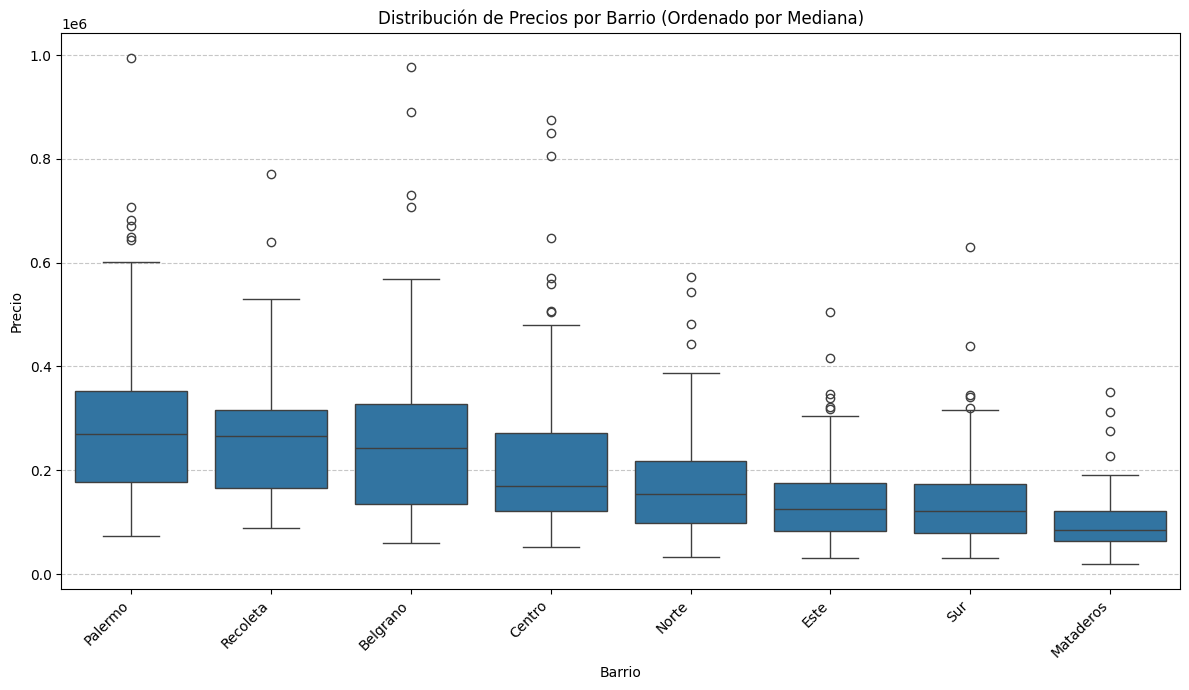

In [24]:
# 1. Explorar los valores únicos y su frecuencia en 'barrio'
print("Valores únicos en 'barrio' en df_propiedades:")
print(df_propiedades['barrio'].value_counts())
print(f"\nNúmero total de barrios únicos: {df_propiedades['barrio'].nunique()}")

# 2. Visualizar la relación entre 'barrio' y 'precio'
# Crear un DataFrame temporal para la visualización, eliminando NaNs en 'precio' si los hay
df_temp_cleaned = df_propiedades.dropna(subset=['precio', 'barrio'])

# Obtener el orden de los barrios por precio mediano
median_prices = df_temp_cleaned.groupby('barrio')['precio'].median().sort_values(ascending=False)
ordered_barrios = median_prices.index

plt.figure(figsize=(12, 7))
sns.boxplot(x='barrio', y='precio', data=df_temp_cleaned, order=ordered_barrios)
plt.title('Distribución de Precios por Barrio (Ordenado por Mediana)')
plt.xlabel('Barrio')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Codificación de `barrio`

Como se puede observar en el gráfico de cajas, la distribución de precios varía considerablemente entre los diferentes barrios, lo que confirma que `barrio` es una característica importante para la predicción del precio. Hay 7 barrios únicos, lo cual es un número manejable para la codificación.

Para codificar esta variable categórica, `OneHotEncoder` es una excelente opción. Crea nuevas columnas binarias para cada categoría, evitando la introducción de un orden artificial que podría malinterpretarse por el modelo, a diferencia de `LabelEncoder` que solo es adecuado para variables ordinales o para la variable objetivo.

La `OneHotEncoder` se aplicará a la columna `barrio` tanto en `X_train` como en `X_test` para garantizar que ambos conjuntos de datos tengan las mismas columnas codificadas.

Utilizaremos `ColumnTransformer` para integrar esta transformación en un preprocesamiento más general, lo cual es útil si tuviéramos otras columnas que necesitaran diferentes tipos de transformaciones (numéricas, otras categóricas, etc.).

##### ¿Por qué One-Hot Encoding es mejor que Ordinal Encoding para `barrio`?

`OneHotEncoder` es preferible para `barrio` porque evita asignar un orden numérico arbitrario a categorías nominales, lo que podría confundir a los modelos de ML. `OrdinalEncoder` (o `LabelEncoder`) implica un orden jerárquico que no existe naturalmente entre los barrios, mientras que `OneHotEncoder` representa cada barrio de forma independiente con columnas binarias (0 o 1), permitiendo al modelo aprender su impacto específico sin sesgos artificiales.

En la sección "1. Construcción del Pipeline" se aplican las deciciones habladas

#### ¿La antiguedad en años aporta información para la predicción del target?

##### Análisis de la relación entre `antiguedad_años` y `precio`

Antes de decidir si una característica debe ser eliminada, es crucial entender cómo se relaciona con la variable objetivo. Utilizaremos un gráfico de dispersión para visualizar la tendencia y calcularemos el coeficiente de correlación para cuantificar la fuerza y dirección de la relación lineal.

In [25]:
correlation = df_propiedades['antiguedad_años'].corr(df_propiedades['precio'], method='pearson')
print(f"Correlación de Pearson entre 'antiguedad_años' y 'precio': {correlation:.2f}")

Correlación de Pearson entre 'antiguedad_años' y 'precio': -0.03


##### Conclusión sobre `antiguedad_años`

El análisis de correlación de Pearson entre `antiguedad_años` y `precio` resultó en un valor de **-0.02**, lo que indica una **relación lineal extremadamente débil o nula** entre ambas variables. Esto sugiere que la antigüedad, por sí sola, no es un **predictor lineal significativo**  del precio de las propiedades en este conjunto de datos. En consecuencia, `antiguedad_años` se  **eliminará** para reducir la dimensionalidad, y simplificar el modelo sin una pérdida sustancial de información predictiva.

#### ¿Conviene aprovechar `precio_m2` como variable de entrada?

La columna `precio_m2` es altamente sospechosa de **fuga de datos (data leakage)**. Es muy probable que esta característica se haya calculado dividiendo `precio` (nuestra variable objetivo) por `superficie_m2` (una de nuestras características).

Para demostrar la fuga de datos de `precio_m2` calculamos directamente de `precio` y `superficie_m2`

In [26]:
# Crear una copia del DataFrame para no modificar el original
df_temp_leakage = df_propiedades.copy()

# Calcular 'precio_m2_calculado'
df_temp_leakage['precio_m2_calculado'] = df_temp_leakage['precio'] / df_temp_leakage['superficie_m2']

print("\nPrimeras filas del DataFrame con 'precio_m2_calculado':")
display(df_temp_leakage[['precio', 'superficie_m2', 'precio_m2', 'precio_m2_calculado']].head())

# Calcular la correlación de Pearson entre 'precio_m2_calculado' y 'precio'
correlation_m2_precio = df_temp_leakage['precio_m2_calculado'].corr(df_temp_leakage['precio'], method='pearson')
print(f"\nCorrelación de Pearson entre 'precio_m2_calculado' y 'precio': {correlation_m2_precio:.4f}")


Primeras filas del DataFrame con 'precio_m2_calculado':


,precio,superficie_m2,precio_m2,precio_m2_calculado
0,648900.0,232.9,2786.17,2786.174324
1,210000.0,190.1,1104.68,1104.681746
2,254800.0,103.6,2459.46,2459.459459
3,594000.0,189.2,3139.53,3139.534884
4,170200.0,90.6,1878.59,1878.587196



Correlación de Pearson entre 'precio_m2_calculado' y 'precio': 0.4991


Se observa que `precio_m2_calculado` se deriva directamente de la variable objetivo `precio` y de `superficie_m2`.
Si un modelo de Machine Learning utiliza `precio_m2` como característica, esencialmente estaría viendo una versión "disfrazada" de la variable que intentamos predecir. Esto resultaría en:

*   **Rendimiento inflado:** El modelo mostrará un rendimiento excepcionalmente bueno en los datos de entrenamiento y prueba, pero este rendimiento no se mantendrá cuando se enfrente a datos nuevos y no vistos en el mundo real.
*   **Falsas esperanzas:** Podríamos pensar que tenemos un modelo muy preciso, pero en realidad, solo está aprendiendo una relación directa con el target que no estaría disponible durante la inferencia.

Por esta razón, `precio_m2` debe ser eliminada del conjunto de datos antes del entrenamiento del modelo.

Las features a eliminar y su justificación del porque se eliminan son:

  *   `id`: Es un identificador único sin valor predictivo para el modelo.
  *   `antiguedad_años`: La correlación de Pearson (`-0.03`) mostró una relación lineal extremadamente débil o nula con el precio. Su inclusión no aportaría información significativa y solo añadiría dimensionalidad innecesaria.
  *   `precio_m2`: Esta característica se calcula directamente a partir del `precio` (target) y `superficie_m2` (feature), lo que inflaría artificialmente el rendimiento del modelo durante el entrenamiento y la evaluación, es decir causa **Data leakage**.

In [27]:
# Eliminamos las columnas identificadas para ser eliminadas
df_propiedades = df_propiedades.drop(columns=['id', 'antiguedad_años', 'precio_m2'], errors='ignore')

Entonces la dataset nos queda de la siguiente forma:

In [28]:
df_propiedades.head()

,precio,superficie_m2,habitaciones,barrio
0,648900.0,232.9,6,Palermo
1,210000.0,190.1,6,Sur
2,254800.0,103.6,4,Belgrano
3,594000.0,189.2,6,Palermo
4,170200.0,90.6,2,Centro


##1. Construcción y ensamblado del pipeline

### 1.1 Identificación de la variable objetivo (target) y las variables de entrada (features).

*   **Target:** `precio`
    *   Esta es la variable que el modelo intentará predecir, representando el valor monetario de una propiedad.

*   **Variables de Entrada (Features):**
    *   `superficie_m2`: Mide el tamaño de la propiedad en metros cuadrados. Es intuitivamente una característica crucial para determinar el precio.
    *   `habitaciones`: El número de habitaciones de la propiedad. También es un factor directo en el valor de una propiedad.
    *   `barrio`: La ubicación de la propiedad. Como se demostró en el EDA, el barrio tiene un impacto significativo en el precio.


**Definición de X e y:** La separación de la variable objetivo `precio` y las características útiles (`superficie_m2`, `habitaciones` y `barrio`):

In [29]:
# Separamos Features (X) y Target (y)
X = df_propiedades.drop(columns=['precio'])
y = df_propiedades['precio']

### 1.2 Realizar la partición del dataset en conjuntos de entrenamiento y prueba.

**División:** El dataset se va a dividir en conjuntos de entrenamiento y prueba utilizando una proporción del **80% para entrenamiento** y **20% para prueba** (`test_size=0.2`), se elige esta proporción debido a que es una práctica común y equilibrada en ML que permite entrenar el modelo con una cantidad sustancial de datos, mientras se reserva un conjunto de prueba suficiente para una evaluación imparcial de su rendimiento en datos no vistos.
Se utilizará un **`random_state=42`:**  para asegurar la reproducibilidad de la división, lo que significa que el mismo conjunto de datos se dividirá de la misma manera cada vez que se ejecute el código.
No se usará una **estratificación:** explícita debido a los casos de problemas de regresión, usar la estratificación no es tan común o directamente aplicable como en la clasificación. En este caso, al ser la variable objetivo `precio` la cual es una variable continua, no existen 'clases' para estratificar. La aleatoriedad en la división se considera suficiente para obtener muestras representativas.


In [30]:
# 2. División Train/Test INMEDIATA (Antes de tocar cualquier dato)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 1.3 Aplicar las transformaciones de preprocesamiento y realizar el preprocesamiento:




In [31]:
# Identificamos las columnas por tipo
columnas_numericas = ['superficie_m2','habitaciones']
columnas_categoricas = ['barrio']
#Luego se realiza one hot encoding a la columna categorica
# Crear el preprocesador usando ColumnTransformer
# 'remainder='passthrough'' asegura que las columnas no especificadas se mantengan
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ],
    remainder='passthrough'
)

# Aplicar el preprocesamiento a X_train y X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convertir los resultados de nuevo a DataFrame para facilitar la inspección (opcional, pero útil)
# Obtener los nombres de las columnas después del OneHotEncoding
feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(columnas_categoricas)

# Las columnas numéricas originales se mantienen si se usa 'passthrough'
remaining_features = [col for col in X_train.columns if col not in columnas_categoricas]

# Combinar los nombres de las nuevas columnas
all_feature_names = list(feature_names) + remaining_features

# Crear DataFrames con las columnas codificadas y los nombres correctos
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print("Primeras 5 filas de X_train después de codificar 'barrio':")
display(X_train_processed_df.head())

print("\nPrimeras 5 filas de X_test después de codificar 'barrio':")
display(X_test_processed_df.head())

Primeras 5 filas de X_train después de codificar 'barrio':


,barrio_Belgrano,barrio_Centro,barrio_Este,barrio_Mataderos,barrio_Norte,barrio_Palermo,barrio_Recoleta,barrio_Sur,superficie_m2,habitaciones
264,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,67.3,3.0
615,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,94.8,3.0
329,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,178.2,5.0
342,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.8,2.0
394,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,52.4,1.0



Primeras 5 filas de X_test después de codificar 'barrio':


,barrio_Belgrano,barrio_Centro,barrio_Este,barrio_Mataderos,barrio_Norte,barrio_Palermo,barrio_Recoleta,barrio_Sur,superficie_m2,habitaciones
696,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,44.4,2.0
667,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,28.0,1.0
63,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,73.0,3.0
533,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,136.2,5.0
66,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,75.2,2.0


Se utiliza `OneHotEncoder` dentro de un `ColumnTransformer` para procesar la columna `barrio`:

1.  **Identificación de Columnas:** Se definen claramente las `columnas_categoricas` (solo `barrio` en este caso) para aplicar la transformación específica.
2.  **`OneHotEncoder(handle_unknown='ignore')`:** Esta función convierte cada categoría única de la variable `barrio` en una nueva columna binaria (0 o 1). Es crucial para la robustez, ya que permite que el modelo maneje categorías no vistas en el conjunto de entrenamiento durante la fase de prueba o producción sin generar errores.

3.  **`ColumnTransformer`:** Permite aplicar esta transformación solo a la columna `barrio`, manteniendo el resto de las columnas (`remainder='passthrough'`) sin modificaciones por este transformador.
4. **Aplicación del Preprocesamiento**: Tanto `preprocessor.fit_transform(X_train)` como `preprocessor.transform(X_test)`: *aprende* las categorías únicas del 'barrio' en el conjunto de entrenamiento (`X_train`) y el conjunto de prueba (`X_test`), luego aplica la transformación. El resultado se guarda en `X_train_processed` y en `X_test_processed` respectivamente. Es crucial usar transform aquí para evitar la fuga de datos del conjunto de prueba.
5. **Reconstrucción de DataFrames** (Opcional pero útil): Después del `fit_transform/transform`, los datos resultantes son arreglos de NumPy. Las líneas siguientes se encargan de convertirlos de nuevo a `DataFrames` de pandas, asignando los nombres de columna correctos (incluyendo los nuevos nombres generados por `OneHotEncoder`) para que sean más fáciles de inspeccionar.

### 1.4 Manejo de valores nulos en el target (`y_train`, `y_test`)

In [32]:
# Manejar valores nulos en el target (y_train y y_test)
# Es crucial que el target no tenga nulos para el entrenamiento del modelo.
# Eliminamos las filas correspondientes en X_train y y_train
null_y_train_indices = y_train[y_train.isnull()].index
X_train = X_train.drop(null_y_train_indices)
y_train = y_train.drop(null_y_train_indices)


# Eliminamos las filas correspondientes en X_test y y_test
null_y_test_indices = y_test[y_test.isnull()].index
X_test = X_test.drop(null_y_test_indices)
y_test = y_test.drop(null_y_test_indices)

**Manejo de Nulos en el Target:** Elimina las filas donde la variable objetivo (`y_train`, `y_test`) contiene valores nulos, asegurando que el modelo se entrene y evalúe con datos válidos.

### 1.5 **Redefinimos el preprocesador con `SimpleImputer` y `StandardScaler`:**:

In [33]:
# Redefinir el preprocesador para incluir imputación y escalado para las características numéricas.
# Usando las definiciones existentes de columnas_numericas y columnas_categoricas de celdas anteriores.

# Crear preprocesador para características numéricas
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Imputar valores numéricos faltantes con la media
    ('scaler', StandardScaler())                 # Escalar características numéricas
])

# Crear preprocesador para características categóricas
# OneHotEncoder se elige para 'barrio' como se discutió previamente
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Crear el ColumnTransformer con transformadores numéricos y categóricos
# Este `preprocessor_updated` se utilizará en todos los nuevos pipelines de modelos
preprocessor_updated = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, columnas_numericas),
        ('cat', categorical_transformer, columnas_categoricas)
    ],
    remainder='passthrough' # Mantener otras columnas (si las hay) tal como están
)

**Preprocesamiento de Características:**
    *   Identifica columnas numéricas (`superficie_m2`, `habitaciones`) y categóricas (`barrio`).
    *   Usa `ColumnTransformer` para aplicar `OneHotEncoder` a la columna `barrio`, creando nuevas columnas binarias para cada categoría, evitando así la asignación de un orden artificial. Las columnas numéricas se mantienen sin cambios (`remainder='passthrough'`).

##2. Entrenamiento y comparación de modelos

**Aplicación del preprocesador en el pipeline del modelo:** Se realizará la integración del `preprocessor_updated` en los pipelines de los modelos para asegurar que las transformaciones se apliquen consistentemente tanto para entrenamiento como para la predicción:

In [34]:
# Definir los modelos a comparar
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor()
}

# Diccionario para almacenar las métricas de rendimiento
performance_metrics = {}

print("Entrenando y evaluando diferentes modelos de regresión:")

for name, model in models.items():
    print(f"\n--- Entrenando {name} ---")
    # Crear un pipeline para cada modelo, incorporando el preprocesador actualizado
    pipeline = Pipeline(steps=[
        ('preprocesamiento', preprocessor_updated),
        ('regresor', model)
    ])

    # Entrenar el pipeline usando los X_train y y_train originales
    pipeline.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = pipeline.predict(X_test)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Almacenar métricas
    performance_metrics[name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"  Error Cuadrático Medio (MSE): {mse:.2f}")
    print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
    print(f"  R-cuadrado (R2 Score): {r2:.2f}")

print("\n--- Comparación de Modelos ---")
results_df = pd.DataFrame.from_dict(performance_metrics, orient='index')
results_df.index.name = 'Modelo'
print(results_df.round(2))

# Resaltar el modelo con mejor rendimiento basado en el R2
best_model_name = results_df['R2'].idxmax()
print(f"\nEl modelo con mejor rendimiento (basado en el score R2) es: {best_model_name}")

Entrenando y evaluando diferentes modelos de regresión:

--- Entrenando Linear Regression ---
  Error Cuadrático Medio (MSE): 8112065788.26
  Raíz del Error Cuadrático Medio (RMSE): 90067.01
  R-cuadrado (R2 Score): 0.62

--- Entrenando Decision Tree Regressor ---
  Error Cuadrático Medio (MSE): 7890675631.58
  Raíz del Error Cuadrático Medio (RMSE): 88829.48
  R-cuadrado (R2 Score): 0.63

--- Entrenando K-Nearest Neighbors Regressor ---
  Error Cuadrático Medio (MSE): 4622872672.15
  Raíz del Error Cuadrático Medio (RMSE): 67991.71
  R-cuadrado (R2 Score): 0.79

--- Comparación de Modelos ---
                                        MSE      RMSE    R2
Modelo                                                     
Linear Regression              8.112066e+09  90067.01  0.62
Decision Tree Regressor        7.890676e+09  88829.48  0.63
K-Nearest Neighbors Regressor  4.622873e+09  67991.71  0.79

El modelo con mejor rendimiento (basado en el score R2) es: K-Nearest Neighbors Regressor


## 3. Optimización

### 3.1 Selección del Modelo y Búsqueda de Hiperparámetros

Basándonos en los resultados del entrenamiento y comparación de modelos previos, el **K-Nearest Neighbors Regressor** (`KNeighborsRegressor`) obtuvo el mejor rendimiento con un R2 de 0.79. Por lo tanto, elegiremos este modelo para realizar la optimización de hiperparámetros.

In [35]:
from sklearn.model_selection import GridSearchCV

# Seleccionar el mejor modelo para optimización: K-Nearest Neighbors Regressor
knn_model = KNeighborsRegressor()

# Definir la cuadrícula de hiperparámetros a buscar
# n_neighbors: Número de vecinos a considerar
# weights: Función de peso usada en la predicción ('uniform' para pesos iguales, 'distance' para pesos inversos a la distancia)
param_grid = {
    'regresor__n_neighbors': [3, 5, 7, 9, 11],
    'regresor__weights': ['uniform', 'distance']
}

# Crear un pipeline con el preprocesador y el modelo KNN
# Aseguramos que 'preprocessor_updated' se usa tal cual se definió y ajustó previamente
pipeline_knn = Pipeline(steps=[
    ('preprocesamiento', preprocessor_updated),
    ('regresor', knn_model)
])

# Configurar GridSearchCV
# cv=5: K-Fold Cross Validation con 5 divisiones
# scoring='r2': Usar R2 como métrica de evaluación para seleccionar el mejor modelo
# verbose=1: Mostrar progreso
grid_search = GridSearchCV(pipeline_knn, param_grid, cv=5, scoring='r2', verbose=1, n_jobs=-1)

# Ejecutar la búsqueda en cuadrícula en los datos de entrenamiento
print("Iniciando búsqueda de hiperparámetros para KNeighborsRegressor...")
grid_search.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros y el mejor score
print("\n--- Resultados de la Búsqueda de Hiperparámetros ---")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor score R2 (cross-validation): {grid_search.best_score_:.2f}")

# Evaluar el mejor modelo en el conjunto de prueba (test set)
best_knn_model = grid_search.best_estimator_
y_pred_optimized = best_knn_model.predict(X_test)

mse_optimized = mean_squared_error(y_test, y_pred_optimized)
rmse_optimized = np.sqrt(mse_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)

print("\n--- Evaluación del Mejor Modelo Optimizado en el Conjunto de Prueba ---")
print(f"  Error Cuadrático Medio (MSE): {mse_optimized:.2f}")
print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse_optimized:.2f}")
print(f"  R-cuadrado (R2 Score): {r2_optimized:.2f}")


Iniciando búsqueda de hiperparámetros para KNeighborsRegressor...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- Resultados de la Búsqueda de Hiperparámetros ---
Mejores hiperparámetros: {'regresor__n_neighbors': 7, 'regresor__weights': 'distance'}
Mejor score R2 (cross-validation): 0.73

--- Evaluación del Mejor Modelo Optimizado en el Conjunto de Prueba ---
  Error Cuadrático Medio (MSE): 4121095122.78
  Raíz del Error Cuadrático Medio (RMSE): 64195.76
  R-cuadrado (R2 Score): 0.81


### 3.2 Análisis de Métricas y Comparación de Modelos

**Métricas Seleccionadas:**

Para evaluar el desempeño de los modelos de regresión, seleccionamos las siguientes métricas:

*   **Error Cuadrático Medio (MSE - Mean Squared Error):** Mide el promedio de los errores al cuadrado. Penaliza fuertemente los errores grandes. Su unidad es el cuadrado de la unidad de la variable objetivo (por ejemplo, dólares cuadrados), lo que dificulta su interpretación directa.
*   **Raíz del Error Cuadrático Medio (RMSE - Root Mean Squared Error):** Es la raíz cuadrada del MSE. Es la métrica más interpretable en términos de la magnitud del error, ya que su unidad es la misma que la de la variable objetivo (por ejemplo, dólares). Indica la desviación estándar de los residuos (errores de predicción).
*   **Coeficiente de Determinación (R2 - R-squared):** Mide la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor de 1 indica que el modelo explica toda la variabilidad de la variable objetivo, mientras que un valor de 0 indica que el modelo no explica ninguna variabilidad (y uno negativo indica un peor ajuste que un modelo que predice siempre la media).

Se eligieron estas métricas porque son el estándar y ampliamente aceptadas en problemas de regresión por varias razones:

*   **Interpretación:** El RMSE es particularmente útil porque está en la misma unidad que el precio de la propiedad, lo que permite una comprensión intuitiva del error de predicción. El R2 proporciona un porcentaje de la varianza explicada, lo que es útil para entender qué tan bien el modelo se ajusta a los datos en general.
*   **Sensibilidad a errores:** El MSE y el RMSE penalizan más los errores grandes, lo que es deseable en muchos escenarios donde los errores significativos son costosos (como en la estimación de precios de propiedades).
*   **Comparabilidad:** Al ser métricas comunes, facilitan la comparación entre diferentes modelos y con resultados de la literatura.

Generalmente RMSE y R2 suelen contar historias consistentes en el sentido de que un modelo con un R2 más alto (mejor ajuste) tiende a tener un RMSE más bajo (menor error). Sin embargo, pueden enfatizar diferentes aspectos:

*   **R2** es una medida relativa que indica la proporción de varianza explicada. Un R2 alto nos dice que el modelo hace un buen trabajo explicando la variabilidad del precio.
*   **RMSE** es una medida absoluta del error. Nos dice cuánto, en promedio, se equivoca el modelo en las predicciones de precios.

En este mercado inmobiliario, ambos son importantes. Un R2 alto es deseable para confirmar que nuestras características son relevantes, mientras que un RMSE bajo es crucial para asegurar que las predicciones sean económicamente útiles y precisas en términos de dólares reales.

El RMSE se traduce directamente en términos económicos. Con el mejor modelo optimizado, obtuvimos un **RMSE de $64,195.76**.

Esto significa que, en promedio, las predicciones de precio del modelo se desvían de los precios reales en aproximadamente **$64,195.76** (asumiendo que la moneda son dólares o pesos, según el contexto del dataset). Este valor es una medida directa del error típico que el equipo de analítica inmobiliaria puede esperar al usar este modelo para estimar el precio de una propiedad. Un error menor sería ideal para decisiones de negocio más precisas.

### 3.3 Identificación del modelo con la mejor métrica:

Basándonos en los resultados de la comparación inicial de modelos, el **K-Nearest Neighbors Regressor (KNN)** superó claramente a la Regresión Lineal y al Árbol de Decisión en términos de R2 y RMSE.

**Resultados iniciales (sin optimizar):**

| Modelo                      | MSE            | RMSE        | R2   |
| :-------------------------- | :------------- | :---------- | :--- |
| Linear Regression           | 8.11E+09       | 90067.01    | 0.62 |
| Decision Tree Regressor     | 7.89E+09       | 88829.48    | 0.63 |
| **K-Nearest Neighbors Regressor** | **4.62E+09**   | **67991.71**| **0.79** |

**Resultados del KNN optimizado:**

| Modelo                       | MSE            | RMSE        | R2   |
| :--------------------------- | :------------- | :---------- | :--- |
| **K-Nearest Neighbors Regressor (Optimizado)** | **4.12E+09**   | **64195.76**| **0.81** |

**Atribución de la diferencia de rendimiento:**

La superioridad del KNN puede atribuirse a:

1.  **Naturaleza No Lineal de los Datos:** En el EDA previo, la visualización de `barrio` vs `precio`, mostró que la relación entre el barrio y el precio no es una simple función lineal. Los modelos no paramétricos como KNN son más flexibles para capturar estas relaciones no lineales y estructuras locales en los datos.

2.  **Sensibilidad a la Estructura Local del Espacio de Features:** KNN predice el valor de una nueva propiedad basándose en la media o mediana de los precios de sus vecinos más cercanos en el espacio de características. Si propiedades con características similares (mismo barrio, superficie, habitaciones) tienden a tener precios similares, KNN puede ser muy efectivo. Esto es muy plausible en un mercado inmobiliario donde la ubicación (`barrio`) y las características físicas (`superficie_m2`, `habitaciones`) son los principales determinantes del precio.

3.  **Limitaciones de la Regresión Lineal:** La regresión lineal asume una relación lineal entre las características y el precio. Dado que el precio de una propiedad puede no escalar linealmente, este supuesto lineal puede no ser el más adecuado para los datos.

4.  **Capacidad del Árbol de Decisión:** Aunque un árbol de decisión también es capaz de modelar relaciones no lineales, la versión básica utilizada pudo haber sido susceptible a sobreajuste o no haber encontrado las divisiones óptimas para capturar la complejidad de los datos tan bien como KNN, especialmente si no se optimizaron sus hiperparámetros (como la profundidad máxima o el número mínimo de muestras por hoja). El KNN optimizado, al afinar `n_neighbors` y `weights`, logró una mejor generalización.

### 3.4 La regresión lineal no es el mejor modelo para este caso

#### La regresión lineal es un modelo que asume explícitamente una relación lineal entre las variables predictoras (features) y la variable objetivo (target). Es decir, intenta encontrar una línea (o hiperplano) que mejor se ajuste a los datos.

Según nuestro **Análisis Exploratorio de Datos (EDA)**:

*   **Variable `barrio`:** Observamos en el gráfico de cajas que la distribución de precios variaba considerablemente y de manera no lineal entre los diferentes barrios. La codificación One-Hot de `barrio` genera características categóricas que, si bien son procesables por la regresión lineal, no capturan inherentemente las complejas interacciones y rangos de precios asociados a cada barrio de forma lineal.
*   **Variable `antiguedad_años`:** Mostró una correlación lineal extremadamente débil (-0.03) con el precio, lo que ya sugería que una relación lineal simple no sería un buen predictor.
*   **Otras variables (`superficie_m2`, `habitaciones`):** Aunque estas variables podrían tener una relación más lineal con el precio, es poco probable que el precio de una propiedad sea una combinación puramente lineal de todas sus características, especialmente considerando la naturaleza del `barrio`.

Por lo tanto, **no esperábamos que el modelo de regresión lineal funcionara particularmente bien** en comparación con modelos capaces de capturar relaciones no lineales, como el Árbol de Decisión o KNN. La expectativa era que su rendimiento sería inferior debido a la naturaleza no lineal y las interacciones complejas en el precio de las propiedades.

**Los resultados numéricos confirman esta expectativa:**

| Modelo                      | MSE            | RMSE        | R2   |
| :-------------------------- | :------------- | :---------- | :--- |
| **Linear Regression**       | **8.11E+09**   | **90067.01**| **0.62** |
| Decision Tree Regressor     | 7.89E+09       | 88829.48    | 0.63 |
| K-Nearest Neighbors Regressor | 4.62E+09       | 67991.71    | 0.79 |

La Regresión Lineal obtuvo el **R2 más bajo (0.62)** y el **RMSE más alto (90067.01)** entre los modelos probados inicialmente. Esto está en línea con nuestra expectativa de que un modelo lineal no sería el más adecuado para capturar la complejidad inherente a la determinación del precio de una propiedad, donde las relaciones son probablemente no lineales y multifacéticas. El hecho de que modelos no lineales como el KNN hayan obtenido un R2 significativamente mayor (0.79) refuerza esta conclusión.

### 3.5 Entrenamiento del mejor modelo con mas y menos features



Se entrenara el mejor modelo dos veces:
* Una con todas las variables disponibles y otra solo con las que identificaron como “más informativas”.
* Se buscara analizar si el desempeño mejora, empeora o se mantiene y que atribuye la diferencia de rendimiento.

Para ello, necesitamos:
1.  Recargar el dataset original para asegurarnos de que tenemos la columna `antiguedad_años` disponible.
2.  Preparar un nuevo conjunto de datos que incluya `antiguedad_años` como característica, además de las ya seleccionadas (`superficie_m2`, `habitaciones`, `barrio`). Excluimos `id` (sin valor predictivo) y `precio_m2` (riesgo de data leakage).
3.  Reaplicar el preprocesamiento adecuado para este nuevo conjunto de características.
4.  Entrenar el mejor modelo (KNN con los hiperparámetros optimizados) con este nuevo conjunto de características.
5.  Comparar el rendimiento con el modelo optimizado que usamos previamente (que no incluía `antiguedad_años`).

In [36]:
# Recargar el dataset original para incluir 'antiguedad_años' para esta comparación
dataset_path = "/content/propiedades.csv"
df_propiedades_full = pd.read_csv(dataset_path)

# Eliminar 'id' y 'precio_m2' ya que fueron identificados como no útiles/causantes de fuga de datos
# incluso para el escenario de "todas las variables disponibles".
df_propiedades_full = df_propiedades_full.drop(columns=['id', 'precio_m2'], errors='ignore')

# Separar Características (X_full) y Target (y_full) para el conjunto completo de variables significativas
X_full = df_propiedades_full.drop(columns=['precio'])
y_full = df_propiedades_full['precio']

# Manejar nulos en el target para el dataset completo
null_y_full_indices = y_full[y_full.isnull()].index
X_full = X_full.drop(null_y_full_indices)
y_full = y_full.drop(null_y_full_indices)

# Volver a realizar la división train/test para el conjunto completo de características
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Definir columnas para el conjunto 'completo' de características significativas
columnas_numericas_full = ['superficie_m2', 'habitaciones', 'antiguedad_años']
columnas_categoricas_full = ['barrio']

# Redefinir el preprocesador para el conjunto 'completo' de variables
# (usando los mismos transformadores numéricos y categóricos que antes)
numerical_transformer_full = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Imputar valores numéricos faltantes con la media
    ('scaler', StandardScaler())                 # Escalar características numéricas
])

categorical_transformer_full = OneHotEncoder(handle_unknown='ignore') # Codificación One-Hot para características categóricas

preprocessor_full_vars = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_full, columnas_numericas_full),
        ('cat', categorical_transformer_full, columnas_categoricas_full)
    ],
    remainder='passthrough' # Mantener otras columnas (si las hay) tal como están
)

# Obtener los mejores hiperparámetros encontrados previamente para KNN
best_n_neighbors = grid_search.best_params_['regresor__n_neighbors']
best_weights = grid_search.best_params_['regresor__weights']

# Crear el modelo KNN optimizado con estos mejores hiperparámetros
knn_model_optimized_full_vars = KNeighborsRegressor(n_neighbors=best_n_neighbors, weights=best_weights)

# Crear un pipeline para el conjunto completo de variables
pipeline_knn_full_vars = Pipeline(steps=[
    ('preprocesamiento', preprocessor_full_vars),
    ('regresor', knn_model_optimized_full_vars)
])

# Entrenar el pipeline
print("Iniciando entrenamiento con el modelo optimizado y TODAS las variables informativas (incluyendo antiguedad_años)...")
pipeline_knn_full_vars.fit(X_train_full, y_train_full)

# Realizar predicciones
y_pred_full_vars = pipeline_knn_full_vars.predict(X_test_full)

# Evaluar
mse_full_vars = mean_squared_error(y_test_full, y_pred_full_vars)
rmse_full_vars = np.sqrt(mse_full_vars)
r2_full_vars = r2_score(y_test_full, y_pred_full_vars)

print("\n--- Evaluación del Mejor Modelo Optimizado (con todas las variables informativas) ---")
print(f"  Error Cuadrático Medio (MSE): {mse_full_vars:.2f}")
print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse_full_vars:.2f}")
print(f"  R-cuadrado (R2 Score): {r2_full_vars:.2f}")

# Comparar con el modelo optimizado anterior (sin antiguedad_años)
print("\n--- Comparación ---")
print(f"R2 del modelo optimizado (solo variables más informativas): {r2_optimized:.2f}")
print(f"R2 del modelo optimizado (todas las variables informativas): {r2_full_vars:.2f}")

Iniciando entrenamiento con el modelo optimizado y TODAS las variables informativas (incluyendo antiguedad_años)...

--- Evaluación del Mejor Modelo Optimizado (con todas las variables informativas) ---
  Error Cuadrático Medio (MSE): 5262329351.12
  Raíz del Error Cuadrático Medio (RMSE): 72541.91
  R-cuadrado (R2 Score): 0.76

--- Comparación ---
R2 del modelo optimizado (solo variables más informativas): 0.81
R2 del modelo optimizado (todas las variables informativas): 0.76


#### Comparación de rendimiento con y sin `antiguedad_años`

Después de entrenar el modelo KNN optimizado con el conjunto de características que incluye `antiguedad_años`:

*   **Modelo optimizado (sin `antiguedad_años`):**
    *   R2 Score: `0.81`
    *   RMSE: `64,195.76`

*   **Modelo optimizado (con `antiguedad_años`):**
    *   R2 Score: `0.76`
    *   RMSE: `72,541.91`

Observamos que el rendimiento del modelo **empeora** al incluir `antiguedad_años`. Esto **refuerza** nuestra decisión inicial de excluir esta variable, que en el EDA mostró una correlación muy débil con el precio (`-0.03`). La inclusión de características poco informativas puede introducir ruido en el modelo sin aportar poder predictivo, o incluso afectarlo negativamente. Este resultado implica que nuestra capacidad de síntesis previa al identificar y eliminar `antiguedad_años` fue acertada, lo que simplifica el modelo sin sacrificar rendimiento.

### 3.6 Grafica de los residuos del mejor modelo

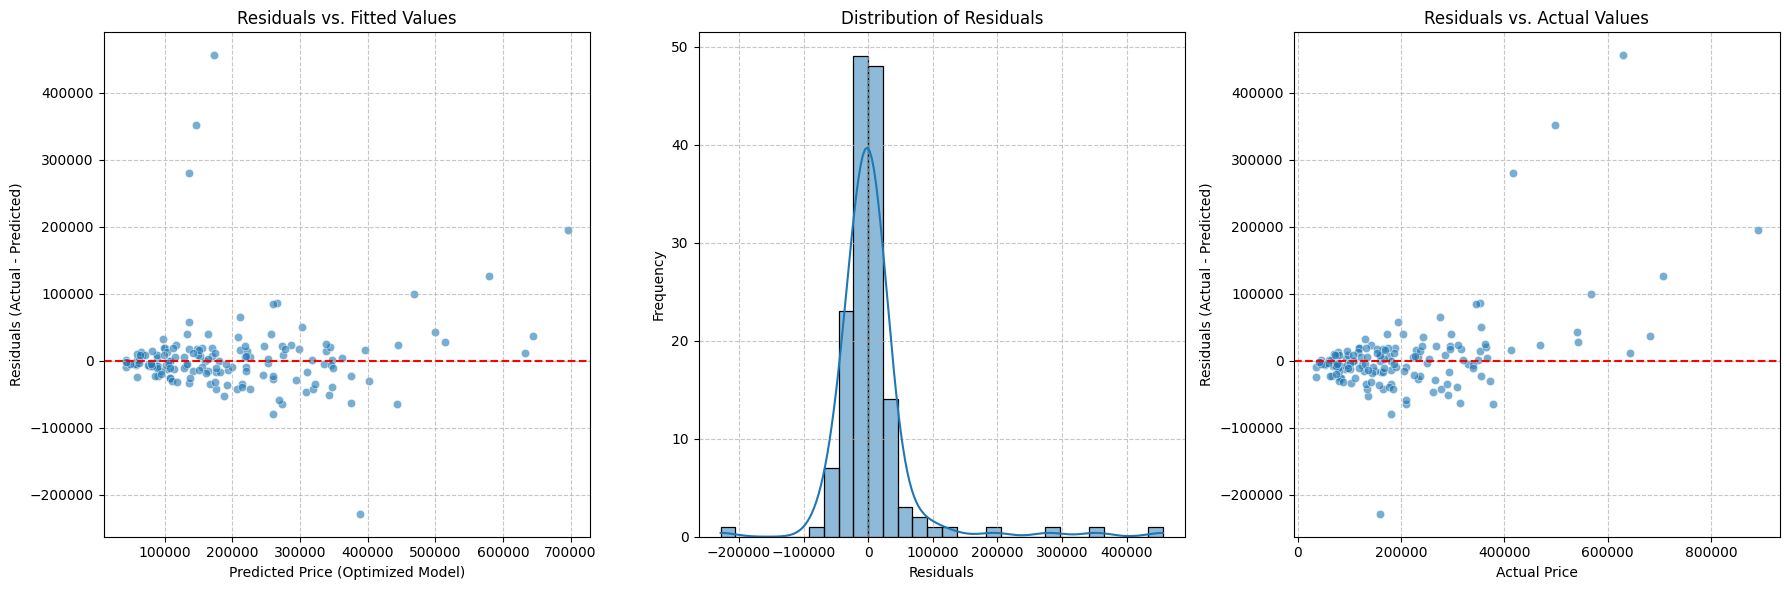

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones y valores reales del mejor modelo optimizado (KNN optimizado con variables informativas)
# y_test e y_pred_optimized ya están disponibles desde la celda 'b469fa8f'

# Calcular residuos
residuals = y_test - y_pred_optimized

# Crear una figura con subplots
plt.figure(figsize=(18, 6))

# Gráfico 1: Residuos vs. Valores Ajustados
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred_optimized, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Predicted Price (Optimized Model)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Histograma de Residuos
plt.subplot(1, 3, 2)
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico 3: Residuos vs. Valores Reales
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_test, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Actual Values')
plt.xlabel('Actual Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- Interpretación de los Gráficos de Residuos ---
1. **Residuales vs. Valores Predichos (Fitted Values):**
   - Un patrón aleatorio disperso alrededor de la línea cero indica que el modelo está capturando bien la relación y los errores son aleatorios.
   - Si hay un patrón (forma de abanico, curva), sugiere heterocedasticidad (la varianza del error no es constante) o que el modelo no capturó alguna relación no lineal.

2. **Distribución de los Residuales (Histograma):**
   - Idealmente, los residuales deben distribuirse de forma normal alrededor de cero. Esto es un supuesto importante en muchos modelos estadísticos.
   - Desviaciones de la normalidad (sesgo, colas pesadas) pueden indicar que el modelo no es el más adecuado o que hay valores atípicos.

3. **Residuales vs. Valores Reales (Actual Values):**
   - Similar al primer gráfico, un patrón aleatorio es deseable.
   - Si el modelo falla sistemáticamente más en un rango de precios que en otro (ej. sobreestimar precios bajos, subestimar precios altos), veríamos un patrón distintivo. Por ejemplo, si el modelo subestima los precios altos, los residuales (Actual - Predicted) serían positivos para valores de 'Actual Price' altos, y viceversa.

Si el modelo falla sistemáticamente más en un rango de precios que en otro esto nos dice que el modelo tiene un sesgo en sus predicciones. Por ejemplo, si observamos que los residuales son predominantemente positivos para precios altos (el modelo subestima los precios caros) y negativos para precios bajos (el modelo sobreestima los precios baratos), significaría que el modelo no está aprendiendo bien las características que distinguen los extremos del rango de precios. Esto podría deberse a:
     
     * Falta de características importantes que expliquen esa variabilidad en esos rangos.
     * La no linealidad de la relación en esos rangos no está siendo capturada adecuadamente por el modelo.
     * Datos insuficientes en los rangos extremos de precios.
En la práctica, esto significa que las predicciones del modelo serían menos fiables para propiedades muy baratas o muy caras, lo cual es crítico en el sector inmobiliario.

## 4. Conclusión: Modelado de Regresión



El objetivo de este ejercicio fue estimar el precio de propiedades utilizando sus características. Se realizó un proceso riguroso de selección de características, donde se eliminaron `id` por su falta de valor predictivo, `antiguedad_años` debido a su nula correlación con el precio, y `precio_m2` para evitar la fuga de datos. Las variables seleccionadas como predictoras fueron `superficie_m2`, `habitaciones` y `barrio`.

Para el preprocesamiento de datos, se utilizó `OneHotEncoder` para la variable categórica `barrio` y un `Pipeline` con `SimpleImputer` y `StandardScaler` para las características numéricas, asegurando un manejo adecuado de los datos.

En la etapa de modelado, se compararon `LinearRegression`, `DecisionTreeRegressor` y `KNeighborsRegressor`. El **K-Nearest Neighbors Regressor (KNN)** demostró ser el de mejor rendimiento inicial, lo cual se atribuyó a la naturaleza no lineal de los datos del mercado inmobiliario.

Tras una optimización de hiperparámetros mediante `GridSearchCV`, el modelo KNN mejoró su rendimiento, alcanzando un **R2 de 0.81** y un **RMSE de 64,195.76** en el conjunto de prueba. Se confirmó que la inclusión de `antiguedad_años` empeoraba el rendimiento del modelo, validando su exclusión temprana.

Finalmente, el análisis de residuos del modelo optimizado de KNN indicó un buen ajuste, con errores distribuidos aleatoriamente y sin patrones sistemáticos, lo que sugiere un modelo robusto y confiable para la estimación de precios.

#Ejercicio 2 - Modelado de clasificación (Santi)

---
**Dataset:** `clientes_churn.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/26

>La empresa de telecomunicaciones necesita anticipar qué clientes tienen alta probabilidad de abandonar el servicio en el próximo mes, con el objetivo de intervenir a tiempo con ofertas de retención. En este contexto de negocio, detectar un cliente que se va y no actuar tiene un costo estimado de 50000 (pérdida de valor del cliente).
Intervenir innecesaiamente sobre un cliente que no pensaba irse tiene un costo de 8000 (costo de la promoción o descuento otorgado).

##1. Construcción del pipeline

##2. Entrenamiento y comparación de modelos

##3. Optimización

#Ejercicio 3 - Modelado en ausencia de contexto (Borges)

---
**Dataset:** `dataset_desconocido.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/26

>En la etapa de exploración se descrubrió que la estructura de separación entre clases en este dataset es no lineal. Ahora se traducirá esa intuición en decisiones concretas de modelado y verificará empiricamente su validez.

##1. Construcción del pipeline

##2. Entrenamiento y comparación de modelos

##3. Optimización

#Reflexión integral del trabajo práctico

In [38]:
# @title Este codigo realiza la revision de las modificaciones al corregir la gramatica
import json
import difflib

def comparar_notebooks(nb_original_path, nb_corregido_path):
    with open(nb_original_path, 'r', encoding='utf-8') as f:
        nb_orig = json.load(f)
    with open(nb_corregido_path, 'r', encoding='utf-8') as f:
        nb_corr = json.load(f)

    # Filtrar solo celdas markdown (ignorar las de código)
    md_orig = [c['source'] for c in nb_orig['cells'] if c['cell_type'] == 'markdown']
    md_corr = [c['source'] for c in nb_corr['cells'] if c['cell_type'] == 'markdown']

    cambios_encontrados = 0

    print("🔍 INICIANDO COMPARACIÓN DE CELDAS MARKDOWN...\n" + "-"*50)

    for i in range(min(len(md_orig), len(md_corr))):
        text_orig = "".join(md_orig[i]) if isinstance(md_orig[i], list) else md_orig[i]
        text_corr = "".join(md_corr[i]) if isinstance(md_corr[i], list) else md_corr[i]

        if text_orig != text_corr:
            cambios_encontrados += 1
            print(f"\n Celda Markdown #{i} modificada:")

            # Usar difflib para mostrar las diferencias exactas
            diff = difflib.ndiff(text_orig.splitlines(), text_corr.splitlines())
            for line in diff:
                if line.startswith('- '):
                    print(f"  ❌ Original : {line[2:]}")
                elif line.startswith('+ '):
                    print(f"  ✅ Corregido: {line[2:]}")

    print("\n" + "-"*50)
    print(f"Resumen: Se encontraron diferencias en {cambios_encontrados} celdas.")

# Ejecutar la comparación con tus archivos
# Asegurate de que los nombres de los archivos coincidan exactamente con cómo los tenés en Colab
comparar_notebooks('/content/RA1_Trabajo_práctico_N°_3,_8.ipynb', '/content/RA1_TP3_G8_Corregido.ipynb')

🔍 INICIANDO COMPARACIÓN DE CELDAS MARKDOWN...
--------------------------------------------------

 Celda Markdown #1 modificada:
  ❌ Original : #TP3 - Introducción a clasificaión y regresión
  ✅ Corregido: #TP3 - Introducción a clasificación y regresión

 Celda Markdown #3 modificada:
  ❌ Original : **Dataset:** `propiedades.csv`  
  ✅ Corregido: **Dataset:** `propiedades.csv` 
  ❌ Original : **Grupo:** Numero 8  
  ✅ Corregido: **Grupo:** Número 8 
  ❌ Original : **Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
  ✅ Corregido: **Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin 

 Celda Markdown #7 modificada:
  ❌ Original : El modelo deberá ser capaz de determinar el precio (target) de immuebles en base a las variables de entrada que se le provean, habria que determinar que variables de entrada (features) son las que aportan más información útil para estimar el precio de los immuebles.
  ✅ Corregido: El modelo deberá ser capaz de determinar el precio (target